#  Análise Exploratória de Dados - Análise Multivariada: Goodreads Dataset

In [41]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.reshaping as rsh

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [42]:
caminho = '../data/interim/books/goodreads_books_enriched.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10897, 18)


---
## Matriz de Dispersão de Valores Numéricos

Nota: Exibindo amostra aleatória de 3000 registros para performance.


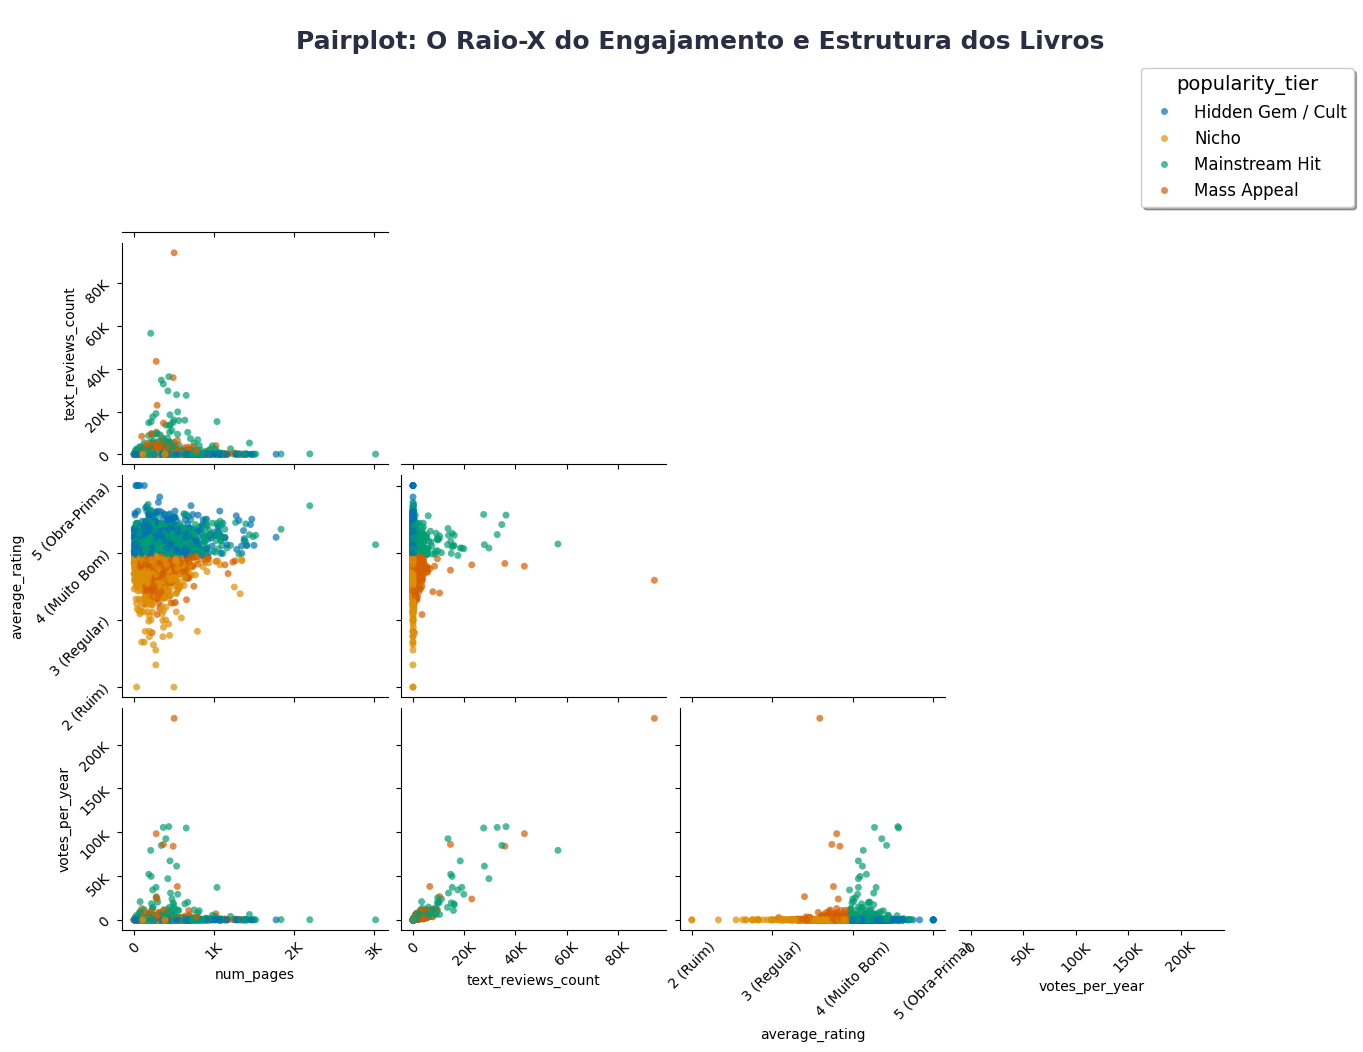

In [43]:
regras_de_escala = {
    'text_reviews_count': {'tipo_dado': 'contagem'},
    'num_pages' : {'tipo_dado': 'contagem'},
    'average_rating' : {'tipo_dado': 'nota_5'},
    'votes_per_year' : {'tipo_dado': 'contagem'}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'num_pages', 
        'text_reviews_count', 
        'average_rating', 
        'votes_per_year'
    ],
    col_log=regras_de_escala,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: O Raio-X do Engajamento e Estrutura dos Livros"
)

Nota: Exibindo amostra aleatória de 3000 registros para performance.


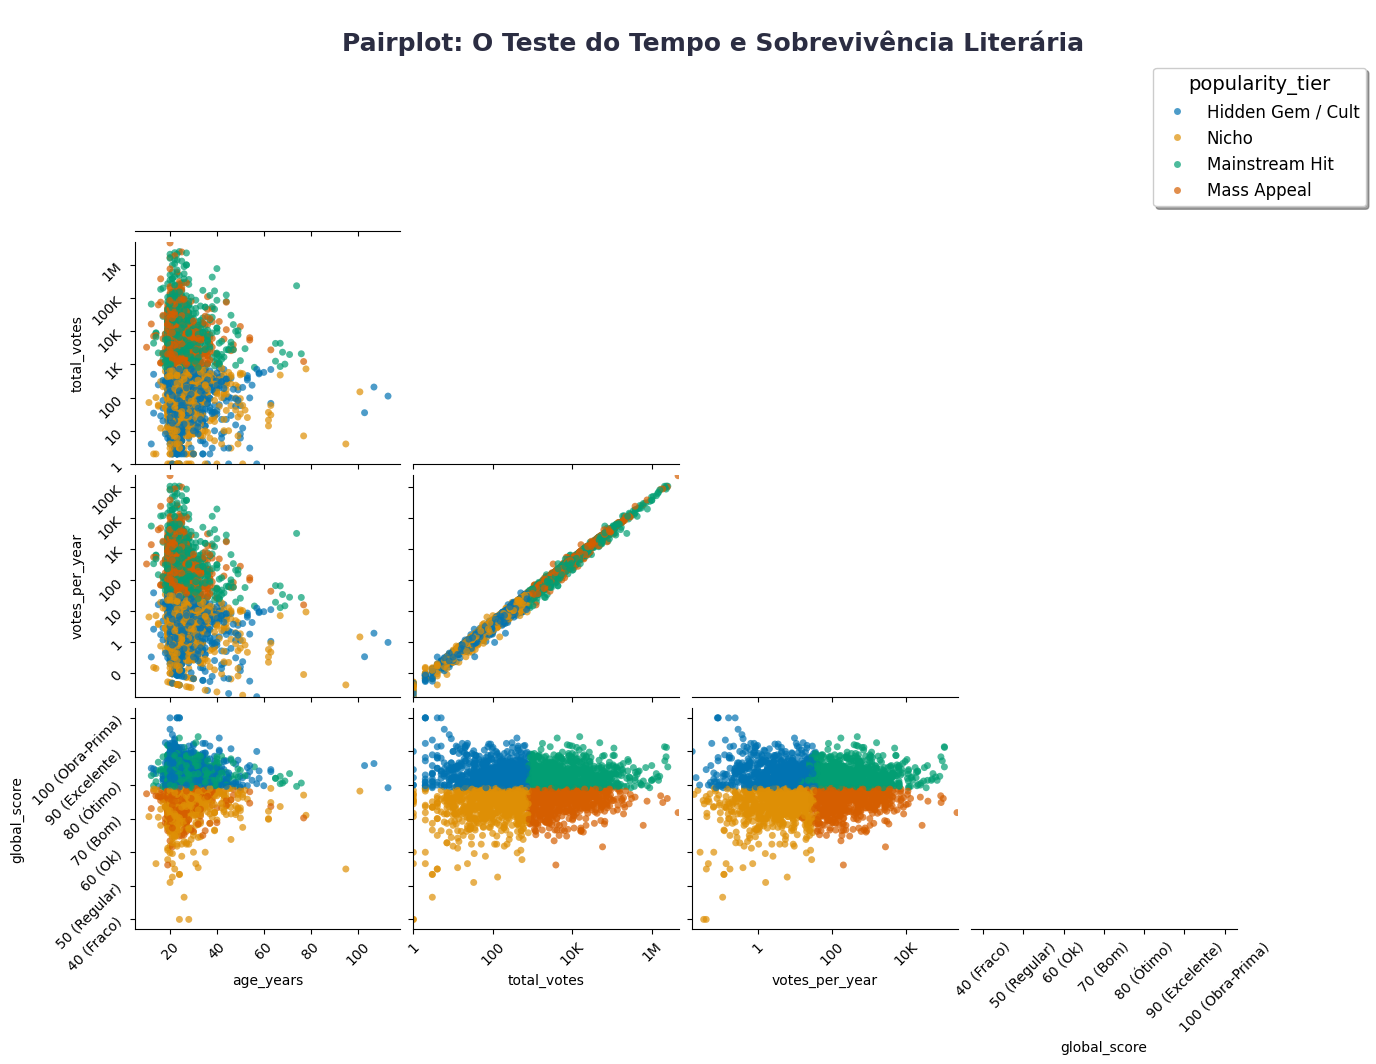

In [44]:
# Regras de escala (Votos precisam de Log para não amassar o gráfico)
regras_tempo = {
    'age_years': {'tipo_dado': 'contagem', 'usar_log': False},
    'total_votes': {'tipo_dado': 'contagem', 'usar_log': True},
    'votes_per_year': {'tipo_dado': 'contagem', 'usar_log': True},
    'global_score': {'tipo_dado': 'nota_100', 'usar_log': False}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'age_years', 
        'total_votes', 
        'votes_per_year', 
        'global_score'
    ],
    col_log=regras_tempo,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: O Teste do Tempo e Sobrevivência Literária"
)

Nota: Exibindo amostra aleatória de 3000 registros para performance.


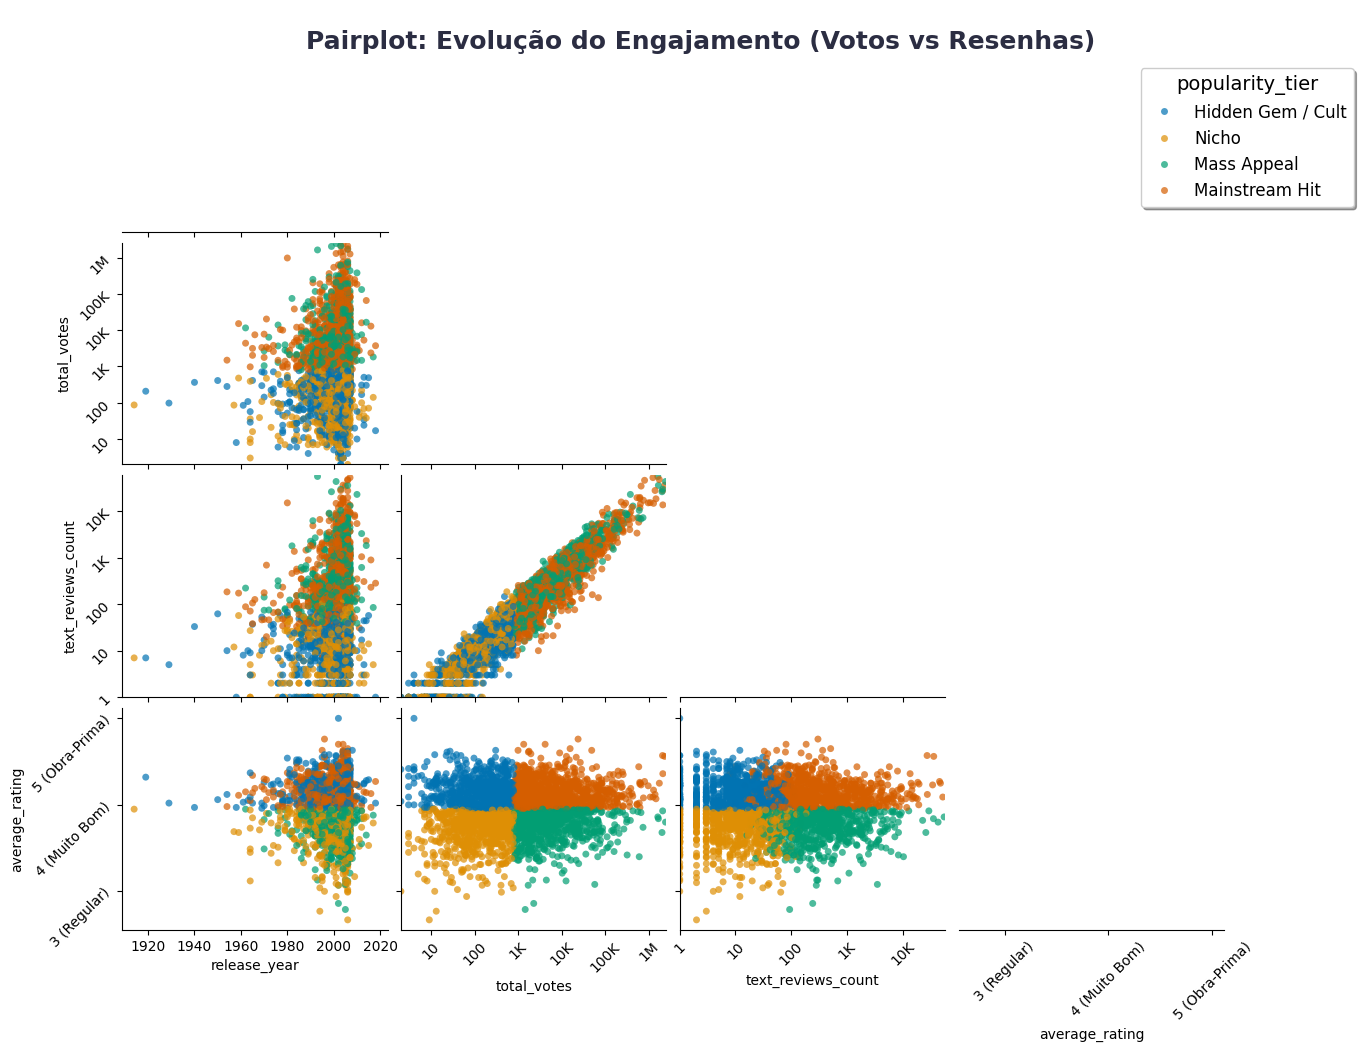

In [45]:
regras_engajamento = {
    'release_year': {'tipo_dado': None, 'usar_log': False}, 
    'total_votes': {'tipo_dado': 'contagem', 'usar_log': True},
    'text_reviews_count': {'tipo_dado': 'contagem', 'usar_log': True},
    'average_rating': {'tipo_dado': 'nota_5', 'usar_log': False}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'release_year', 
        'total_votes', 
        'text_reviews_count', 
        'average_rating'
    ],
    col_log=regras_engajamento,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: Evolução do Engajamento (Votos vs Resenhas)"
)

Nota: Exibindo amostra aleatória de 3000 registros para performance.


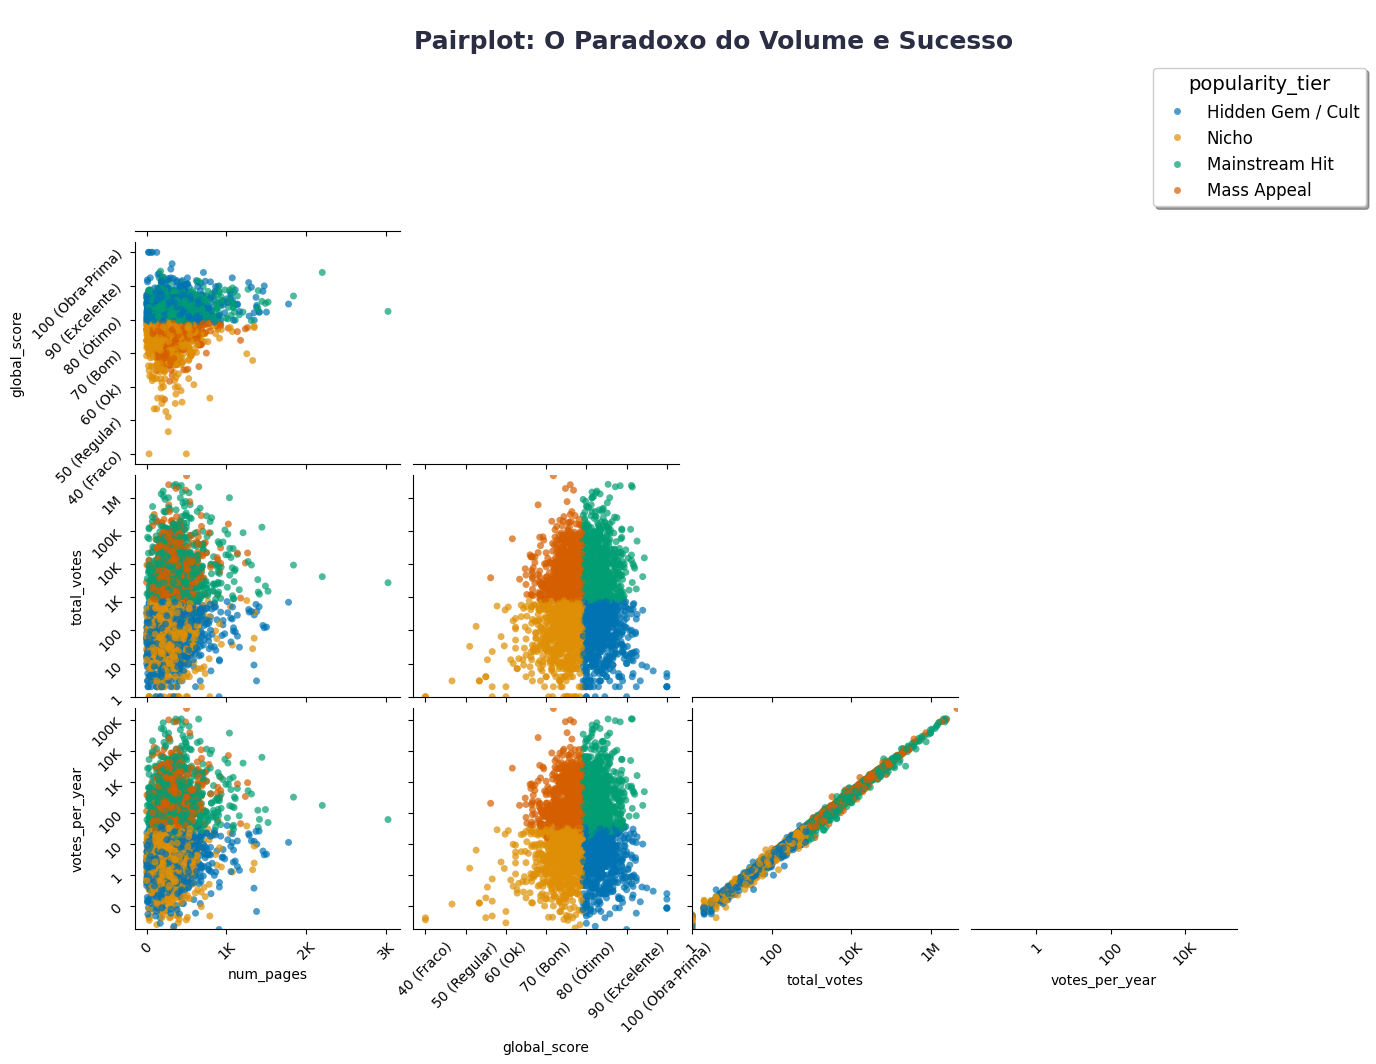

In [46]:
regras_volume = {
    'num_pages': {'tipo_dado': 'contagem', 'usar_log': False},
    'global_score': {'tipo_dado': 'nota_100', 'usar_log': False},
    'votes_per_year': {'tipo_dado': 'contagem', 'usar_log': True},
    'total_votes': {'tipo_dado': 'contagem', 'usar_log': True}
}

graf.grafico_pairplot_numericos(
    df_plot=df_books,
    cols_focadas=[
        'num_pages', 
        'global_score', 
        'total_votes', 
        'votes_per_year'
    ],
    col_log=regras_volume,        
    coluna_hue='popularity_tier',  
    altura_painel=2.5,
    titulo="Pairplot: O Paradoxo do Volume e Sucesso"
)